## ЛР 2.2. Статистические оценки параметров распределения

**Выполнили**: Павлова С.И., Ровнягина М.А., Котяева А.Р.

Исходные данные:
1) интервальный ряд распределения среднего возраста людей, совершивших преступления в Москве в 2021 году;
2) случайная выборка значений возраста преступников.

In [105]:
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

### 0. Подготовка исходных данных

In [106]:
data = pd.read_table('../data/moscow.txt', header=None)[0]
N = len(data)

mean = data.mean()

#### Объём повторной выборки

$$n = \frac{t^2\,\sigma^2}{\delta^2}.$$

При $\gamma = 0{,}95$ принимаем $t = 1{,}96$ по таблице функции Лапласа. Точность оценки $\delta = 3$ года.

In [107]:
t = 1.96
delta = 3
sigma = data.std(ddof=0)

n_exact = t**2 * sigma**2 / delta**2
n = math.ceil(n_exact)
print(f'Расчётное n = {n_exact:.4f}, принятое n = {n}')

Расчётное n = 61.8570, принятое n = 62


#### Формирование 36 повторных выборок

Отбор выполняется случайно с возвращением, в каждой выборке $n$ наблюдений. Далее в лабораторной работе будем рассматривать первую выборку.

In [108]:
random.seed(2021)

sample_count = 36
samples = [ random.choices(data.tolist(), k=n) for _ in range(sample_count) ]
sample_means = np.array([np.mean(sample) for sample in samples])

means_df = pd.DataFrame({
    'Объём n': n,
    'Выборочная средняя': sample_means,
})
means_df.round(3)

,Объём n,Выборочная средняя
0,62,35.839
1,62,34.452
2,62,33.468
3,62,36.452
4,62,34.403
5,62,34.242
6,62,35.290
7,62,36.984
8,62,34.919
9,62,35.823


#### Интервальный ряд распределения среднего возраста

- левая граница — минимум выборочных средних, округлённый вниз;
- правая граница — максимум выборочных средних, округлённый вверх;
- длина интервала $h = 1$ год;
- используются полуинтервалы $[x_{i-1}; x_i)$, последний интервал — отрезок.

In [109]:
left = math.floor(sample_means.min())
right = math.ceil(sample_means.max())
h = 1

bins = np.arange(left, right + h, h)
counts, _ = np.histogram(sample_means, bins=bins)

interval = pd.DataFrame({
    'Интервал': [f'[{bins[i]}; {bins[i + 1]}{"]" if i == len(bins) - 2 else ")"}'
                 for i in range(len(bins) - 1)],
    'x_l': bins[:-1],
    'x_r': bins[1:],
    'x_i*': (bins[:-1] + bins[1:]) / 2,
    'n_i': counts,
    'w_i': counts / sample_count,
})

print(f'Минимальная выборочная средняя: {sample_means.min():.6f}')
print(f'Максимальная выборочная средняя: {sample_means.max():.6f}')
interval

Минимальная выборочная средняя: 31.161290
Максимальная выборочная средняя: 38.338710


,Интервал,x_l,x_r,x_i*,n_i,w_i
0,[31; 32),31,32,31.5,1,0.027778
1,[32; 33),32,33,32.5,2,0.055556
2,[33; 34),33,34,33.5,3,0.083333
3,[34; 35),34,35,34.5,7,0.194444
4,[35; 36),35,36,35.5,8,0.222222
5,[36; 37),36,37,36.5,9,0.250000
6,[37; 38),37,38,37.5,5,0.138889
7,[38; 39],38,39,38.5,1,0.027778


### 1. Выравнивание статистического ряда по нормальному закону. Оценка параметров методом моментов

#### 1.1. Точечные оценки параметров методом моментов

Считаем, что средний возраст $\bar{X}$ (ряд из $m = 36$ выборочных средних) распределён нормально.

**Метод моментов:** приравниваем теоретические моменты к выборочным и получаем оценки параметров:

$$a^* = \bar{x}_в = \frac{1}{m}\sum x_i^* n_i, \qquad \sigma^* = \sqrt{D_в}, \quad D_в = \frac{1}{m}\sum (x_i^* - \bar{x}_в)^2 n_i.$$

In [110]:
m = sample_count
x_mid, n_i = interval['x_i*'], interval['n_i']

x_mean = (x_mid * n_i).sum() / m
D_v = ((x_mid - x_mean) ** 2 * n_i).sum() / m

a_star = x_mean
sigma_star = math.sqrt(D_v)

pd.DataFrame({
    'Величина': ['Выборочная средняя x̄в', 'Выборочная дисперсия Dв',
                 'Оценка a* = x̄в', 'Оценка σ* = √Dв'],
    'Значение': [x_mean, D_v, a_star, sigma_star],
}).round(4)

,Величина,Значение
0,Выборочная средняя x̄в,35.4722
1,Выборочная дисперсия Dв,2.5270
2,Оценка a* = x̄в,35.4722
3,Оценка σ* = √Dв,1.5897


#### 1.2. Выравнивание ряда: теоретические частоты

**Выравнивание:** находим теоретические частоты, какие были бы у ряда при точно нормальном законе:

$$z_i = \frac{x_i - a^*}{\sigma^*}, \qquad p_i = \Phi(z_i) - \Phi(z_{i-1}), \qquad n_i' = m \cdot p_i,$$

где $\Phi$ — функция Лапласа. Крайние границы заменяем на $\pm\infty$, чтобы $\sum p_i = 1$.

In [111]:
def laplace(z):
    # Φ(z) = F₀(z) − 0.5
    return stats.norm.cdf(z) - 0.5

z_l = (interval['x_l'] - a_star) / sigma_star
z_r = (interval['x_r'] - a_star) / sigma_star
z_l.iloc[0] = -np.inf
z_r.iloc[-1] = np.inf

align = pd.DataFrame({
    'Интервал': interval['Интервал'],
    'x_i*': x_mid,
    'n_i': n_i,
    'z_i-1': z_l,
    'z_i': z_r,
    'Φ(z_i-1)': laplace(z_l),
    'Φ(z_i)': laplace(z_r),
})
align['p_i'] = align['Φ(z_i)'] - align['Φ(z_i-1)']
align["n_i'"] = m * align['p_i']

total = pd.DataFrame([{'Интервал': 'Σ', 'n_i': align['n_i'].sum(),
                       'p_i': align['p_i'].sum(), "n_i'": align["n_i'"].sum()}])

pd.concat([align, total], ignore_index=True).round(2)

,Интервал,x_i*,n_i,z_i-1,z_i,Φ(z_i-1),Φ(z_i),p_i,n_i'
0,[31; 32),31.5,1,-inf,-2.18,-0.50,-0.49,0.01,0.52
1,[32; 33),32.5,2,-2.18,-1.56,-0.49,-0.44,0.05,1.64
2,[33; 34),33.5,3,-1.56,-0.93,-0.44,-0.32,0.12,4.22
3,[34; 35),34.5,7,-0.93,-0.30,-0.32,-0.12,0.21,7.42
4,[35; 36),35.5,8,-0.30,0.33,-0.12,0.13,0.25,8.89
5,[36; 37),36.5,9,0.33,0.96,0.13,0.33,0.20,7.26
6,[37; 38),37.5,5,0.96,1.59,0.33,0.44,0.11,4.04
7,[38; 39],38.5,1,1.59,inf,0.44,0.50,0.06,2.01
8,Σ,NaN,36,NaN,NaN,NaN,NaN,1.00,36.00


#### 1.3. Гистограмма частот и аппроксимирующая её кривая Гаусса

**Кривая Гаусса** в масштабе гистограммы относительных частот: вероятность попасть в интервал длины $h$ приблизительно равна $p_i \approx h\,f(x_i^*)$, поэтому плотность умножаем на $h$:

$$y(x) = h\,f(x)

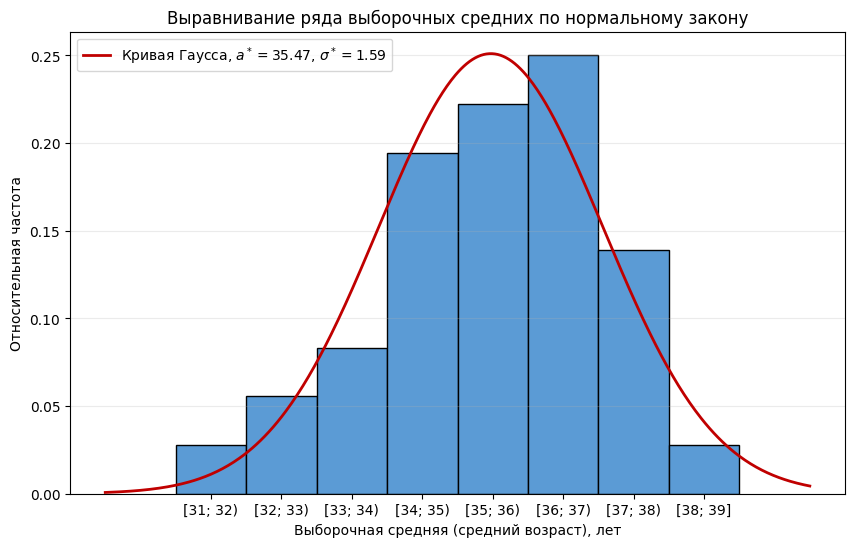

In [112]:
xs = np.linspace(bins[0] - 1, bins[-1] + 1, 500)
gauss = h * stats.norm.pdf(xs, loc=a_star, scale=sigma_star)

xs_pos = (xs - bins[0]) / h - 0.5

plt.figure(figsize=(10, 6))
plt.bar(interval['Интервал'],
        interval['w_i'],
        color='#5B9BD5',
        edgecolor='black',
        width=1)
plt.plot(xs_pos, gauss, color='#C00000', lw=2,
         label=f'Кривая Гаусса, $a^*={a_star:.2f}$, $\\sigma^*={sigma_star:.2f}$')
plt.xlabel('Выборочная средняя (средний возраст), лет')
plt.ylabel('Относительная частота')
plt.title('Выравнивание ряда выборочных средних по нормальному закону')
plt.legend()
plt.grid(axis='y', alpha=0.25)
plt.show()

### 2. Доверительный интервал для математического ожидания при неизвестном σ

Так как $\sigma$ неизвестно, вместо него используется **исправленное среднее квадратическое отклонение**:

$$s = \sqrt{s^2}, \qquad s^2 = \frac{1}{n-1}\sum_{j=1}^{n}\left(x_j - \bar{x}_в\right)^2 = \frac{n}{n-1}\,D_в.$$

**Интервальная оценка** (доверительный интервал):

$$\bar{x}_в - t_\gamma \frac{s}{\sqrt{n}} < a < \bar{x}_в + t_\gamma \frac{s}{\sqrt{n}},$$

где $t_\gamma = t(\gamma, n)$ — квантиль распределения Стьюдента уровня $\dfrac{1+\gamma}{2}$ с $n-1$ степенями свободы (`stats.t.ppf`).

**Точность оценки**:

$$\delta = t_\gamma \frac{s}{\sqrt{n}}.$$

Рассмотрим первую выборку из samples.

In [113]:
sample_idx = 0
sample = np.array(samples[sample_idx])
n = len(sample)

print(f'Объём выборки n = {n}')
print(sample)

Объём выборки n = 62
[21 22 36 25 67 27 35 27 44 41 48 22 29 45 36 38 26 19 69 29 41 34 33 48
 24 33 23 40 46 35 46 46 19 47 45 31 33 47 31 24 35 48 29 42 23 29 40 47
 42 26 45 25 29 34 31 28 37 43 24 48 49 36]


In [114]:
gamma = 0.95

x_bar = sample.mean()                               
s = sample.std(ddof=1)              
t_gamma = stats.t.ppf((1 + gamma) / 2, df=n - 1)   
delta = t_gamma * s / math.sqrt(n)
a_left, a_right = x_bar - delta, x_bar + delta

print(f'Точечная оценка x̄_в     = {x_bar:.4f}')
print(f'Исправленное СКО s      = {s:.4f}')
print(f'Квантиль Стьюдента t_γ  = {t_gamma:.4f}')
print(f'Точность δ = t_γ·s / √n = {delta:.4f}')
print(f'Интервальная оценка     : {a_left:.4f} < a < {a_right:.4f}')

Точечная оценка x̄_в     = 35.8387
Исправленное СКО s      = 10.6835
Квантиль Стьюдента t_γ  = 1.9996
Точность δ = t_γ·s / √n = 2.7131
Интервальная оценка     : 33.1256 < a < 38.5518


In [115]:
covered = a_left < mean < a_right
print(f'Генеральная средняя a = {mean:.4f}')
print(f'Попадает ли a в доверительный интервал: {"да" if covered else "нет"}')

Генеральная средняя a = 35.3730
Попадает ли a в доверительный интервал: да
